In [12]:
### GET PATHS samples 

In [13]:
folder_root = "/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATERIAL/_ALL_3_PROD_stems_S/_25_07_VOCAL"


In [14]:
# -----######-----###### STRICT 3-LEVEL MP3 PATH EXTRACTOR -----######-----###### #
import os
import pandas as pd
from tqdm import tqdm

def _paths_1707_strict3_GET_df_mp3(folder_root):
    """
    Collect only .mp3 file paths exactly three folder levels deep inside folder_root.
    Example: folder_root/level1/level2/level3/*.mp3
    """
    all_paths = []

    level1 = [os.path.join(folder_root, d1) for d1 in os.listdir(folder_root)
              if os.path.isdir(os.path.join(folder_root, d1)) and not d1.startswith(".")]

    for path1 in tqdm(level1, desc="📁 Level 1"):
        level2 = [os.path.join(path1, d2) for d2 in os.listdir(path1)
                  if os.path.isdir(os.path.join(path1, d2)) and not d2.startswith(".")]

        for path2 in level2:
            level3 = [os.path.join(path2, d3) for d3 in os.listdir(path2)
                      if os.path.isdir(os.path.join(path2, d3)) and not d3.startswith(".")]

            for path3 in level3:
                for file in os.listdir(path3):
                    if file.lower().endswith('.mp3') and not file.startswith(".") and not file.startswith("._"):
                        full_path = os.path.join(path3, file)
                        if os.path.isfile(full_path):
                            all_paths.append(full_path)

    return pd.DataFrame({'Path': all_paths})


In [15]:
folder_root = "/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATERIAL/_ALL_3_PROD_stems_S"
df = _paths_1707_strict3_GET_df_mp3(folder_root)

print(df.head(10))
len(df) # total should be 72292 but there are 29 samples missing 

📁 Level 1: 100%|███████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  9.38it/s]

                                                Path
0  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
1  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
2  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
3  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
4  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
5  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
6  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
7  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
8  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...
9  /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...


72263

In [16]:
72263 +29

72292

In [17]:
# -----######-----###### FINAL SMART PARSER (FIXED id_sample sb1_v4 CASE) -----######-----###### #

import os
import re
import pandas as pd
from tqdm import tqdm

def _stem_1710_nodict_GET_df_keys(path_list):
    rows = []

    for path in tqdm(path_list, desc="🎯 Parsing Stem Filenames"):
        base = os.path.basename(path)
        name = os.path.splitext(base)[0]

        # Extract BPM from end
        bpm_match = re.search(r'-(\d{2,3})\.mp3$', base)
        bpm_sample = bpm_match.group(1) if bpm_match else None

        # ID Full Sample: e.g. sb1_v4-7134d
        id_stem_sample_match = re.search(r'_(s[a-zA-Z0-9]+_[vdb]\d+-[0-9a-zA-Z]+)', name)
        id_stem_sample = id_stem_sample_match.group(1) if id_stem_sample_match else None
        id_stem = id_stem_sample.split("-")[1] if id_stem_sample else None

        # ✅ Corrected: id_sample = sb1_v4
        id_sample_match = re.search(r'_(s[a-zA-Z0-9]+_[vdb]\d+)-', name)
        id_sample = id_sample_match.group(1) if id_sample_match else None

        # Extract key string after luX-
        key_string = ""
        try:
            clean_name = name.replace(f"-{bpm_sample}", "") if bpm_sample else name
            lu_match = re.search(r'lu[A-Z][-_]([\w#\-]+)$', clean_name)
            if lu_match:
                key_string = lu_match.group(1)
        except:
            pass

        # Tokenize key pairs
        tokens = re.split(r'[-_]', key_string)
        pairs = []
        i = 0
        while i < len(tokens) - 1:
            dj = tokens[i]
            mus = tokens[i + 1]
            if re.match(r'^\d{1,2}[AB]$', dj):
                pairs.append((mus, dj))
                i += 2
            else:
                i += 1
        pairs = pairs[::-1]

        # Assign keys
        key_1, key_dj_1 = pairs[0] if len(pairs) > 0 else (None, None)
        key_2, key_dj_2 = pairs[1] if len(pairs) > 1 else (None, None)
        key_3, key_dj_3 = pairs[2] if len(pairs) > 2 else (None, None)

        rows.append({
            "Path": path,
            "base_name": name,
            "id_sample": id_sample,
            "id_stem_sample": id_stem_sample,
            "id_stem": id_stem,
            "bpm_sample": bpm_sample,
            "key_string": key_string,
            "key_1": key_1,
            "key_dj_1": key_dj_1,
            "key_2": key_2,
            "key_dj_2": key_dj_2,
            "key_3": key_3,
            "key_dj_3": key_dj_3
        })

    return pd.DataFrame(rows)


In [18]:
df_keys = _stem_1710_nodict_GET_df_keys(df['Path'])


🎯 Parsing Stem Filenames: 100%|████████████████████████████████████| 72263/72263 [00:00<00:00, 190676.21it/s]


#### CHECK FREQ of samples 

# KEYS

🎯 key_1: ✅ No missing
🎯 key_2: ✅ No missing
🎯 key_3: ✅ No missing
🎯 key_dj_1: ✅ No missing
🎯 key_dj_2: ✅ No missing
🎯 key_dj_3: ✅ No missing


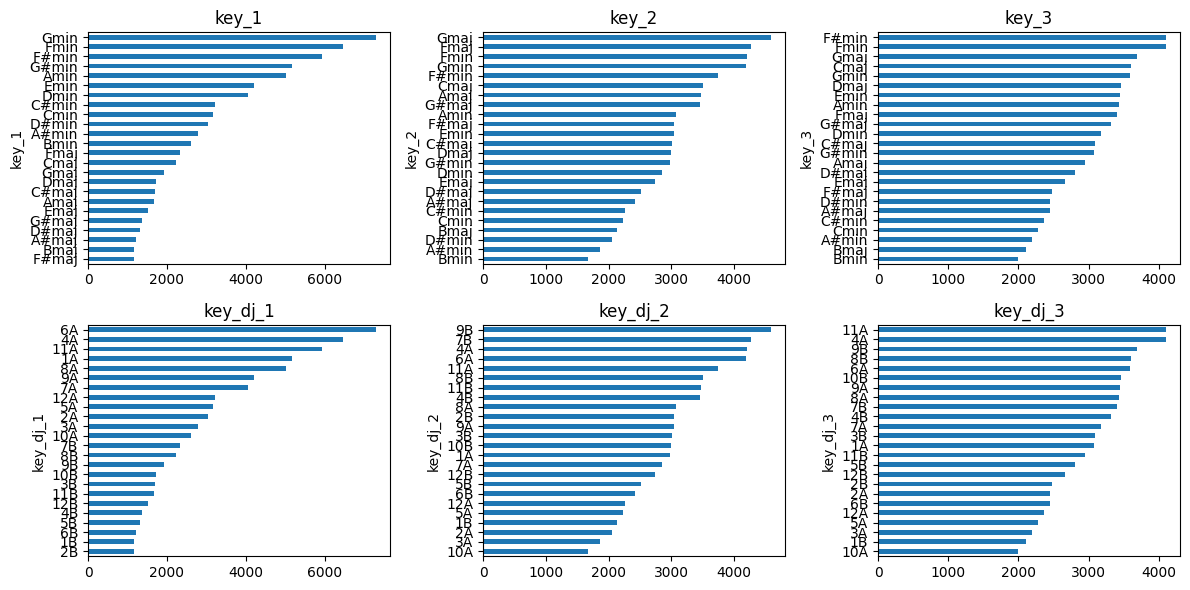

In [19]:
import matplotlib.pyplot as plt

cols = ['key_1','key_2','key_3','key_dj_1','key_dj_2','key_dj_3']

# Print missing info
for col in cols:
    n_miss = df_keys[col].isna().sum()
    print(f"🎯 {col}: {'❌ Missing values: ' + str(n_miss) if n_miss else '✅ No missing'}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    df_keys[col].value_counts(dropna=False).plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


# BPM 


🎯 bpm_sample: ✅ No missing


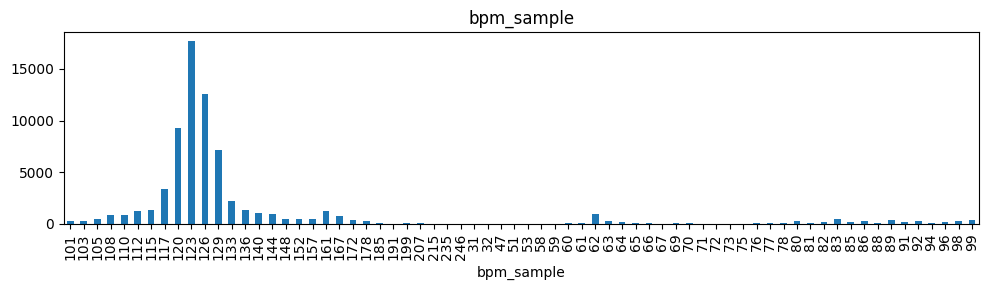

In [20]:
# ✅ Check for missing values
n_miss = df_keys['bpm_sample'].isna().sum()
print(f"\n🎯 bpm_sample: {'❌ Missing values: ' + str(n_miss) if n_miss else '✅ No missing'}")

# 🔢 Frequency table
#print(df_keys['bpm_sample'].value_counts(dropna=False).sort_index())

# 📊 Bar plot
df_keys['bpm_sample'].value_counts().sort_index().plot(kind='bar', figsize=(10, 3), title='bpm_sample')
plt.tight_layout()
plt.show()


In [21]:
df_keys.head()

,Path,base_name,id_sample,id_stem_sample,id_stem,bpm_sample,key_string,key_1,key_dj_1,key_2,key_dj_2,key_3,key_dj_3
0,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s15_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s15_b4,s15_b4-71429,71429,101,10B-Dmaj-8A-Amin_11B-Amaj,Amaj,11B,Amin,8A,Dmaj,10B
1,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s24_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s24_b4,s24_b4-71429,71429,101,12B-Emaj-11B-Amaj_8A-Amin,Amin,8A,Amaj,11B,Emaj,12B
2,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s22_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s22_b4,s22_b4-71429,71429,101,2A-D#min-10A-Bmin_1B-Bmaj,Bmaj,1B,Bmin,10A,D#min,2A
3,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s11_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s11_b4,s11_b4-71429,71429,101,10A-Bmin-12B-Emaj_8A-Amin,Amin,8A,Emaj,12B,Bmin,10A
4,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s83_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s83_b4,s83_b4-71429,71429,101,10B-Dmaj-11A-F#min_10A-Bmin,Bmin,10A,F#min,11A,Dmaj,10B


In [22]:
# -----######-----###### DIAGNOSTICS FOR STEM ID COLUMNS -----######-----###### #

def _stem_1710_diag_GET_missing_and_duplicates(df_keys):
    print("🔍 Checking for missing values in ID columns...\n")
    df_missing_ids = df_keys[df_keys[['id_sample', 'id_stem_sample', 'id_stem']].isna().any(axis=1)]
    
    print(f"🚨 Rows with missing values in any of ['id_sample', 'id_stem_sample', 'id_stem']: {len(df_missing_ids)}")
    if not df_missing_ids.empty:
        print("\n🧾 Sample of rows with missing values:")
        print(df_missing_ids[['Path', 'id_sample', 'id_stem_sample', 'id_stem']].head(5))
    else:
        print("✅ No missing values detected.")

    print("\n🔍 Checking uniqueness of 'id_stem_sample'...")
    if df_keys['id_stem_sample'].is_unique:
        print("✅ All values in 'id_stem_sample' are unique >>>>>>>> YESSSSS .")
    else:
        print("🚨 Duplicate values found in 'id_stem_sample'!")
        dupes = df_keys[df_keys.duplicated('id_stem_sample', keep=False)]
        print("\n🧾 Sample of duplicated 'id_stem_sample' values:")
        print(dupes[['id_stem_sample', 'Path']].head(5))

    return df_missing_ids
df_missing = _stem_1710_diag_GET_missing_and_duplicates(df_keys)


🔍 Checking for missing values in ID columns...

🚨 Rows with missing values in any of ['id_sample', 'id_stem_sample', 'id_stem']: 0
✅ No missing values detected.

🔍 Checking uniqueness of 'id_stem_sample'...
✅ All values in 'id_stem_sample' are unique >>>>>>>> YESSSSS .


In [24]:
print("🎯 Missing values per column:\n")
print(df_keys.isna().sum())

print("\n🚨 Columns with at least one missing value:\n")
print(df_keys.columns[df_keys.isna().any()].tolist())

print(f"\n📊 Total missing values in entire DataFrame: {df_keys.isna().sum().sum()}")


🎯 Missing values per column:

Path              0
base_name         0
id_sample         0
id_stem_sample    0
id_stem           0
bpm_sample        0
key_string        0
key_1             0
key_dj_1          0
key_2             0
key_dj_2          0
key_3             0
key_dj_3          0
dtype: int64

🚨 Columns with at least one missing value:

[]

📊 Total missing values in entire DataFrame: 0


In [26]:
df_keys.head()

,Path,base_name,id_sample,id_stem_sample,id_stem,bpm_sample,key_string,key_1,key_dj_1,key_2,key_dj_2,key_3,key_dj_3
0,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s15_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s15_b4,s15_b4-71429,71429,101,10B-Dmaj-8A-Amin_11B-Amaj,Amaj,11B,Amin,8A,Dmaj,10B
1,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s24_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s24_b4,s24_b4-71429,71429,101,12B-Emaj-11B-Amaj_8A-Amin,Amin,8A,Amaj,11B,Emaj,12B
2,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s22_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s22_b4,s22_b4-71429,71429,101,2A-D#min-10A-Bmin_1B-Bmaj,Bmaj,1B,Bmin,10A,D#min,2A
3,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s11_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s11_b4,s11_b4-71429,71429,101,10A-Bmin-12B-Emaj_8A-Amin,Amin,8A,Emaj,12B,Bmin,10A
4,/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATER...,_s83_b4-71429-11BAmaj---25-VARIOUS-411srcbasss...,s83_b4,s83_b4-71429,71429,101,10B-Dmaj-11A-F#min_10A-Bmin,Bmin,10A,F#min,11A,Dmaj,10B


# get the category for each STEM 

In [27]:
# -----######-----###### ADD 'cat_STEM' FROM PATH -----######-----###### #
def _path_1707_catstem_GET_column(df):
    from tqdm import tqdm
    tqdm.pandas()

    def extract_cat(path):
        parts = path.split("/")
        for i, p in enumerate(parts):
            if p.startswith("_25_07_") and i + 1 < len(parts):
                return p.replace("_25_07_", "")  # Strip prefix, leave just "BASS"
        return None  # fallback if structure is unexpected

    df['cat_STEM'] = df['Path'].progress_apply(extract_cat)
    return df


In [32]:

#!#!#!#!#! RUNNING STATEMENTS #!#!#!#!#!
df_keys = _path_1707_catstem_GET_column(df_keys)


100%|███████████████████████████████████████████████████████████████| 72263/72263 [00:00<00:00, 640873.92it/s]


In [39]:
print(df_keys['cat_STEM'].value_counts(dropna=False).sort_index())

cat_STEM
BASS      9197
DRUM     30088
VOCAL    32978
Name: count, dtype: int64


# EXPORT pkl excel and csv  ! 

In [43]:
# -----######-----###### EXPORT DF TO PKL, CSV ONLY -----######-----###### #
import pandas as pd
import os

def _export_1710_dfkeys_GET_all_formats(df_keys, export_dir, filename_base):
    """
    Exports df_keys as PKL and CSV in the provided directory using the exact filename_base.
    """
    os.makedirs(export_dir, exist_ok=True)

    path_pkl = os.path.join(export_dir, f"{filename_base}.pkl")
    path_csv = os.path.join(export_dir, f"{filename_base}.csv")

    df_keys.to_pickle(path_pkl)
    df_keys.to_csv(path_csv, index=False)

    print(f"✅ Exported as:\n📦 PKL  : {path_pkl}\n📄 CSV  : {path_csv}")


In [45]:

# Example usage
export_dir = "/Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATERIAL/_ALL_3_PROD_stems_S"  # ← or any folder you choose
filename_base = "_25_07_ii_STEM_SAMPLE_level-info_ID_and_BPM_and_KEYstring"  # ← change this, no need to type 'loc_' first

_export_1710_dfkeys_GET_all_formats(df_keys, export_dir, filename_base)


✅ Exported as:
📦 PKL  : /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATERIAL/_ALL_3_PROD_stems_S/_25_07_ii_STEM_SAMPLE_level-info_ID_and_BPM_and_KEYstring.pkl
📄 CSV  : /Users/yerik/Music/_4_MUSIC_PROD/_0_PROD_MATERIAL/_ALL_3_PROD_stems_S/_25_07_ii_STEM_SAMPLE_level-info_ID_and_BPM_and_KEYstring.csv
